In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/Colab\ Notebooks

 dynamic_transactions.csv   notebooks_01_eda.ipynb	  scaler.pkl
 feature_list.pkl	    notebooks_02_modeling.ipynb   template
 final_fraud_model.pkl	    optimal_threshold.pkl
 FLASK.ipynb		   'role_2(updated).ipynb'


In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [5]:
# ✅ Loading the continuous PaySim dataset (live URL, 24/7 stream)
import time

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dynamic_transactions.csv')

print(f"✅ Loaded {len(df)} transactions from continuous PaySim stream")
print(f"Fraud: {df['Fraudulent'].sum()} | Legit: {(df['Fraudulent']==0).sum()}")

# Simulate continuous data arriving in batches
def stream_batch(dataframe, batch_size=1000, batch_num=0):
    start = batch_num * batch_size
    batch = dataframe.iloc[start : start + batch_size].copy()
    print(f"📡 Batch {batch_num+1} | {len(batch)} transactions | "
          f"Fraud in batch: {batch['Fraudulent'].sum()} | "
          f"Time: {pd.Timestamp.now().strftime('%H:%M:%S')}")
    return batch

print("\nSimulating live data stream:\n")
for i in range(3):
    stream_batch(df, batch_size=1000, batch_num=i)
    time.sleep(1)

print("\n✅ Stream active — dataset ready for anomaly detection")
df.head()

✅ Loaded 6362620 transactions from continuous PaySim stream
Fraud: 8213 | Legit: 6354407

Simulating live data stream:

📡 Batch 1 | 1000 transactions | Fraud in batch: 9 | Time: 08:12:15
📡 Batch 2 | 1000 transactions | Fraud in batch: 5 | Time: 08:12:16
📡 Batch 3 | 1000 transactions | Fraud in batch: 2 | Time: 08:12:17

✅ Stream active — dataset ready for anomaly detection


,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Hour,txn_count_user,user_avg_amt,amt_deviation,night_txn,device_change,Fraudulent
0,8087,9839.64,1,0,0,0,73,5,1,1,1,9839.64,0.0,1,0,0
1,2589,1864.28,1,2,0,0,1632,2,1,1,1,1864.28,0.0,1,0,0
2,6349,181.00,0,1,1,0,200,2,1,1,1,181.00,0.0,1,1,1
3,722,181.00,2,0,1,0,406,2,0,1,1,181.00,0.0,1,0,1
4,818,11668.14,1,0,0,1,512,1,1,1,1,11668.14,0.0,1,0,0


In [6]:
df = df.drop(columns=[c for c in ['Transaction_ID', 'Timestamp'] if c in df.columns])

In [7]:
y = df["Fraudulent"]

xgb_features = [
    'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Device_Used',
    'Location', 'Previous_Fraudulent_Transactions', 'Account_Age',
    'Number_of_Transactions_Last_24H', 'Payment_Method', 'Hour',
    'night_txn', 'device_change'
]
X = df[xgb_features].copy()
print(f"✅ Using {X.shape[1]} features (matching Brinda's XGBoost): {X.columns.tolist()}")

✅ Using 12 features (matching Brinda's XGBoost): ['User_ID', 'Transaction_Amount', 'Transaction_Type', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Hour', 'night_txn', 'device_change']


In [8]:
# Fill any NaNs in the 12 selected features
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print("Remaining NaNs:", X.isnull().sum().sum())
print(f"Feature count going into autoencoder: {X.shape[1]}")

Remaining NaNs: 0
Feature count going into autoencoder: 12


In [9]:
# Dynamic dataset columns are already numerically encoded
# No label encoding needed
print("✅ Categorical features already encoded in dynamic dataset")

✅ Categorical features already encoded in dynamic dataset


In [10]:
# Use Brinda's scaler so inference matches production
import joblib
drive_path = '/content/drive/MyDrive/Colab Notebooks/'

xgb_scaler = joblib.load(drive_path + 'scaler.pkl')
X_scaled = xgb_scaler.transform(X)   # transform only — NOT fit_transform
print("✅ Using shared scaler — matches app.py")

✅ Using shared scaler — matches app.py


In [11]:
import numpy as np

# Use only 20,000 normal rows for training
normal_idx  = np.where(y == 0)[0]
sample_idx  = np.random.choice(normal_idx, size=min(20000, len(normal_idx)), replace=False)
X_train_normal = X_scaled[sample_idx]

input_dim    = X_train_normal.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
encoder     = Dense(encoding_dim, activation="relu")(input_layer)
decoder     = Dense(input_dim, activation="linear")(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer="adam", loss="mse")

print(f"Training on {len(X_train_normal):,} rows...")

autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=5,
    batch_size=512,
    shuffle=True,
    verbose=1
)

# Predict on max 30,000 rows only
all_idx     = np.random.choice(len(X_scaled), size=min(30000, len(X_scaled)), replace=False)
X_sample    = X_scaled[all_idx]
y_sample    = np.array(y)[all_idx]

reconstructions = autoencoder.predict(X_sample, verbose=0)
mse             = np.mean(np.power(X_sample - reconstructions, 2), axis=1)

threshold   = np.percentile(mse, 95)
y_pred_auto = (mse > threshold).astype(int)

print("Autoencoder Results")
print(confusion_matrix(y_sample, y_pred_auto))
print(classification_report(y_sample, y_pred_auto))

Training on 20,000 rows...
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 5.5293
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5615
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8826
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3243
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8193
Autoencoder Results
[[28472  1477]
 [   28    23]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     29949
           1       0.02      0.45      0.03        51

    accuracy                           0.95     30000
   macro avg       0.51      0.70      0.50     30000
weighted avg       1.00      0.95      0.97     30000



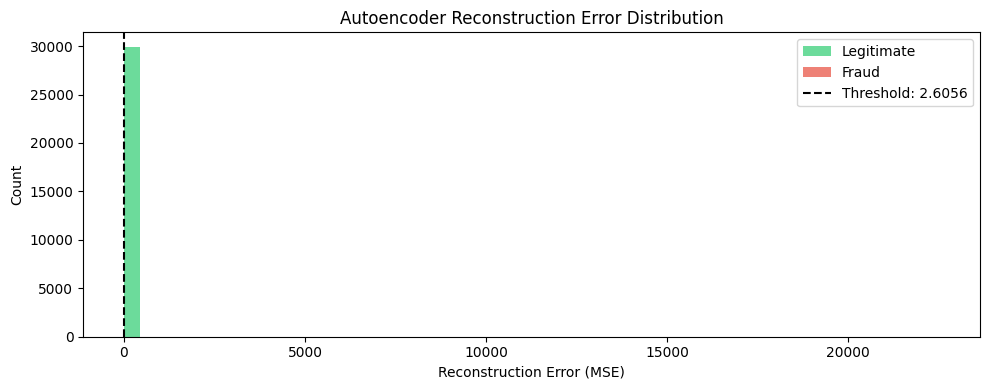

Legitimate transactions in sample: 29949
Fraud transactions in sample:      51


In [12]:
import matplotlib.pyplot as plt

# Use y_sample and mse from the fast autoencoder cell above
# (NOT the full y — that was replaced by sampling)

plt.figure(figsize=(10, 4))
plt.hist(mse[y_sample == 0], bins=50, alpha=0.7,
         color='#2ecc71', label='Legitimate')
plt.hist(mse[y_sample == 1], bins=50, alpha=0.7,
         color='#e74c3c', label='Fraud')
plt.axvline(threshold, color='black',
            linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Legitimate transactions in sample: {(y_sample==0).sum()}")
print(f"Fraud transactions in sample:      {(y_sample==1).sum()}")

In [13]:
from sklearn.neighbors import LocalOutlierFactor

lof_size = min(10000, len(X_sample))
lof_idx  = np.random.choice(len(X_sample), size=lof_size, replace=False)

X_lof    = X_sample[lof_idx]
y_lof    = np.array(y_sample)[lof_idx]

lof        = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred_lof = lof.fit_predict(X_lof)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

print("LOF Results")
print(confusion_matrix(y_lof, y_pred_lof))
print(classification_report(y_lof, y_pred_lof))

LOF Results
[[8993  988]
 [   7   12]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      9981
           1       0.01      0.63      0.02        19

    accuracy                           0.90     10000
   macro avg       0.51      0.77      0.49     10000
weighted avg       1.00      0.90      0.95     10000



In [14]:
# KMeans — use X_sample for speed
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_sample)

distances    = np.min(kmeans.transform(X_sample), axis=1)
threshold_km = np.percentile(distances, 90)
y_pred_km    = (distances > threshold_km).astype(int)

print("K-Means Results")
print(confusion_matrix(y_sample, y_pred_km))
print(classification_report(y_sample, y_pred_km))

K-Means Results
[[26978  2971]
 [   22    29]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     29949
           1       0.01      0.57      0.02        51

    accuracy                           0.90     30000
   macro avg       0.50      0.73      0.48     30000
weighted avg       1.00      0.90      0.95     30000



In [15]:
# Random Forest — use X_sample and y_sample
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.3, random_state=42, stratify=y_sample)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))


[[8985    0]
 [  15    0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8985
           1       0.00      0.00      0.00        15

    accuracy                           1.00      9000
   macro avg       0.50      0.50      0.50      9000
weighted avg       1.00      1.00      1.00      9000

ROC AUC: 0.9214320163235021


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
print("=" * 55)
print("   ANOMALY DETECTION COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Method':<25} {'Type':<15} {'Approach'}")
print("-" * 55)
print(f"{'Autoencoder':<25} {'Unsupervised':<15} Reconstruction error")
print(f"{'LOF':<25} {'Unsupervised':<15} Density based")
print(f"{'K-Means':<25} {'Unsupervised':<15} Distance based")
print(f"{'Random Forest':<25} {'Supervised':<15} Label based")
print("=" * 55)
print("✅ Unsupervised models detect fraud without labels")
print("✅ Supervised model uses labeled fraud data")

   ANOMALY DETECTION COMPARISON SUMMARY
Method                    Type            Approach
-------------------------------------------------------
Autoencoder               Unsupervised    Reconstruction error
LOF                       Unsupervised    Density based
K-Means                   Unsupervised    Distance based
Random Forest             Supervised      Label based
✅ Unsupervised models detect fraud without labels
✅ Supervised model uses labeled fraud data


In [17]:
!pip install networkx -q

import networkx as nx
import matplotlib.pyplot as plt

In [18]:
# ✅ Reload dataset for Graph Analysis section
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dynamic_transactions.csv')

print(f"✅ Reloaded {len(df)} transactions for graph analysis")
df.head()

✅ Reloaded 6362620 transactions for graph analysis


,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Hour,txn_count_user,user_avg_amt,amt_deviation,night_txn,device_change,Fraudulent
0,8087,9839.64,1,0,0,0,73,5,1,1,1,9839.64,0.0,1,0,0
1,2589,1864.28,1,2,0,0,1632,2,1,1,1,1864.28,0.0,1,0,0
2,6349,181.00,0,1,1,0,200,2,1,1,1,181.00,0.0,1,1,1
3,722,181.00,2,0,1,0,406,2,0,1,1,181.00,0.0,1,0,1
4,818,11668.14,1,0,0,1,512,1,1,1,1,11668.14,0.0,1,0,0


In [19]:
# SPEED FIX FOR GRAPH — sample 500 users only
sample_users = np.random.choice(
    df['User_ID'].unique(),
    size=min(500, df['User_ID'].nunique()),
    replace=False
)
df_graph = df[df['User_ID'].isin(sample_users)].copy()

print(f"✅ Graph will use {len(df_graph)} rows | {df_graph['User_ID'].nunique()} users")

✅ Graph will use 317849 rows | 500 users


In [20]:
# Build graph using df_graph (500 users only — fast)
G = nx.Graph()

for user in df_graph['User_ID'].unique():
    G.add_node(user)

for location in df_graph['Location'].dropna().unique():
    users = df_graph[df_graph['Location'] == location]['User_ID'].unique()
    for i in range(len(users)):
        for j in range(i+1, len(users)):
            G.add_edge(users[i], users[j])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 500
Number of edges: 124750


/tmp/ipykernel_4887/254018837.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


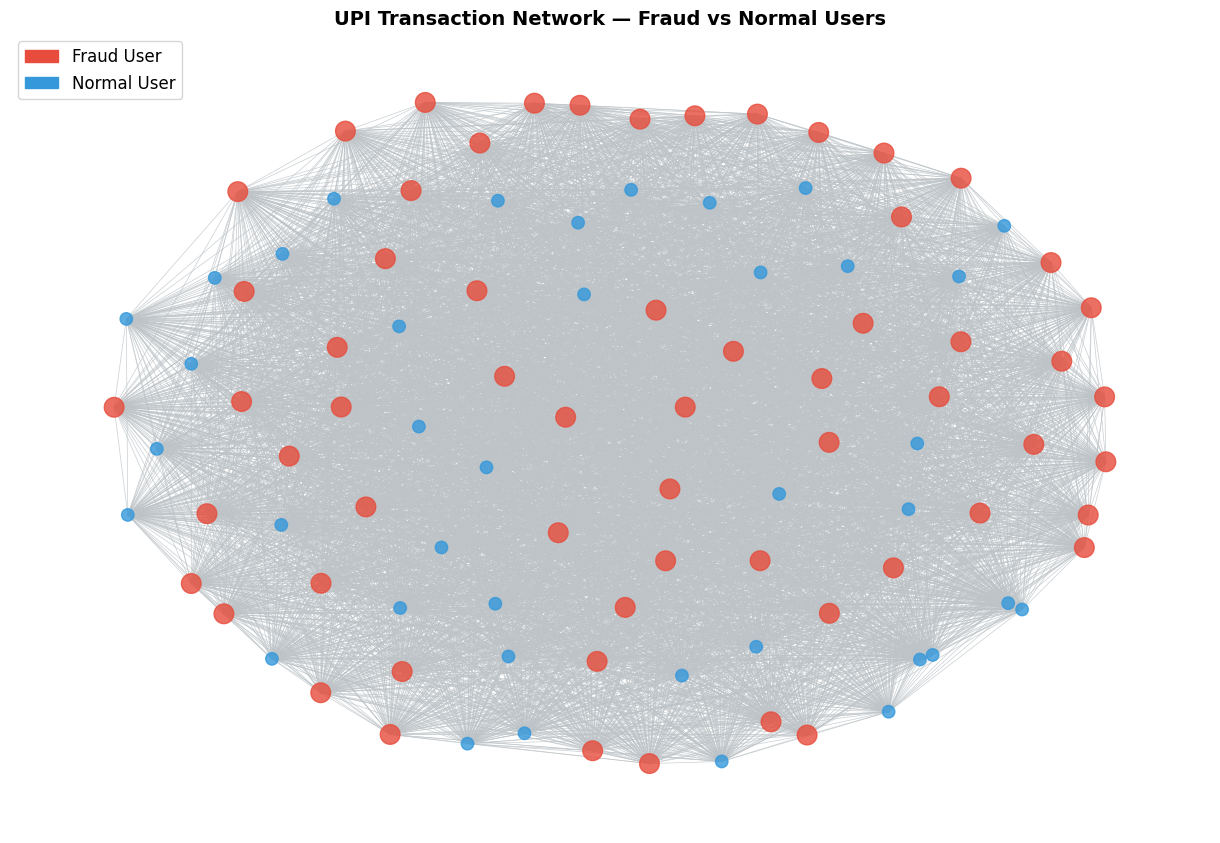

Total nodes shown: 100
Red nodes (fraud): 61
Blue nodes (normal): 39


In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Sample 100 nodes so graph is readable
sample_nodes = list(G.nodes())[:100]
subgraph = G.subgraph(sample_nodes)

# Color fraud users red, normal users blue
fraud_users_set = set(df_graph[df_graph['Fraudulent'] == 1]['User_ID'].unique())
colors = ['#e74c3c' if node in fraud_users_set
          else '#3498db' for node in subgraph.nodes()]

# Size fraud nodes bigger so they stand out
sizes = [200 if node in fraud_users_set
         else 80 for node in subgraph.nodes()]

# Draw the graph
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph,
        pos=pos,
        node_color=colors,
        node_size=sizes,
        with_labels=False,
        edge_color='#bdc3c7',
        width=0.5,
        alpha=0.8)

# Add legend manually
import matplotlib.patches as mpatches
fraud_patch  = mpatches.Patch(color='#e74c3c', label='Fraud User')
normal_patch = mpatches.Patch(color='#3498db', label='Normal User')
plt.legend(handles=[fraud_patch, normal_patch],
           loc='upper left', fontsize=12)

plt.title('UPI Transaction Network — Fraud vs Normal Users',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total nodes shown: {subgraph.number_of_nodes()}")
print(f"Red nodes (fraud): {sum(1 for n in subgraph.nodes() if n in fraud_users_set)}")
print(f"Blue nodes (normal): {sum(1 for n in subgraph.nodes() if n not in fraud_users_set)}")

In [22]:
mule_candidates = df_graph[
    (df_graph['Number_of_Transactions_Last_24H'] > 10) &
    (df_graph['Previous_Fraudulent_Transactions'] > 0)
]['User_ID'].unique()

print(f"Potential Mule-Like Accounts detected: {len(mule_candidates)}")
print("User IDs:", mule_candidates[:10])

Potential Mule-Like Accounts detected: 450
User IDs: [3429 9870 5584 3165 2183 1530 1502 8206 6464 8044]


/tmp/ipykernel_4887/3010740179.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


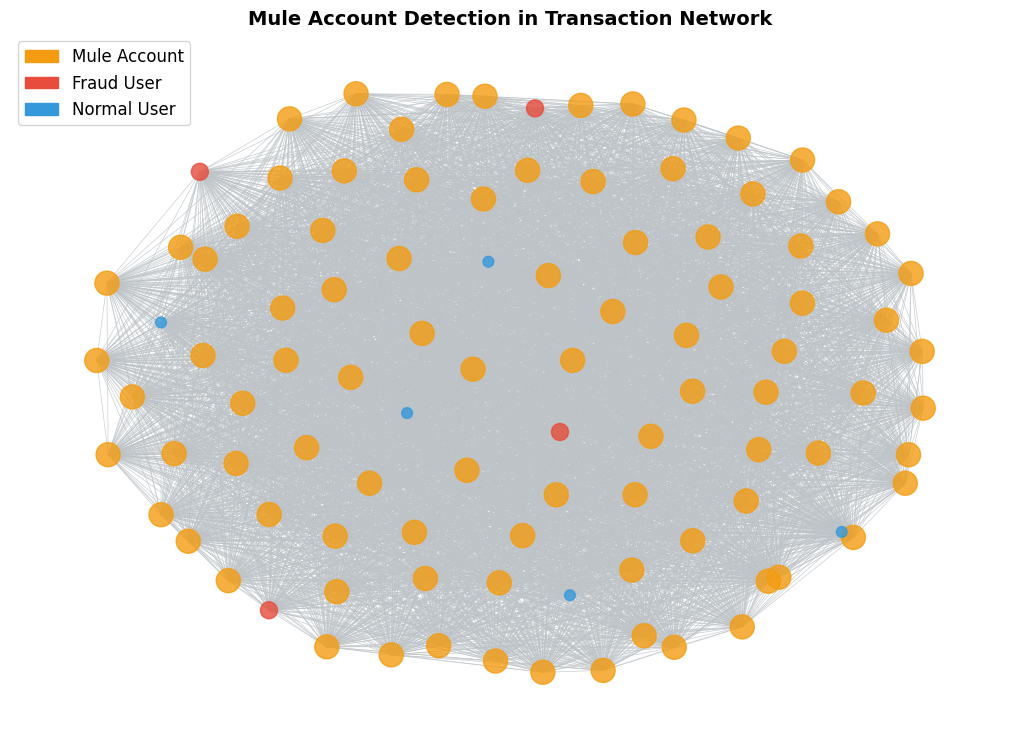

Mule accounts highlighted: 91


In [23]:
plt.figure(figsize=(10, 7))

# Highlight mule accounts in the graph
mule_set = set(mule_candidates)

sample_nodes = list(G.nodes())[:100]
subgraph = G.subgraph(sample_nodes)

# 3 colors — mule = orange, fraud = red, normal = blue
colors = []
for node in subgraph.nodes():
    if node in mule_set:
        colors.append('#f39c12')   # orange = mule
    elif node in fraud_users_set:
        colors.append('#e74c3c')   # red = fraud
    else:
        colors.append('#3498db')   # blue = normal

sizes = [300 if node in mule_set else
         150 if node in fraud_users_set else
         60 for node in subgraph.nodes()]

pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph,
        pos=pos,
        node_color=colors,
        node_size=sizes,
        with_labels=False,
        edge_color='#bdc3c7',
        width=0.5,
        alpha=0.8)

# Legend
mule_patch   = mpatches.Patch(color='#f39c12', label='Mule Account')
fraud_patch  = mpatches.Patch(color='#e74c3c', label='Fraud User')
normal_patch = mpatches.Patch(color='#3498db', label='Normal User')
plt.legend(handles=[mule_patch, fraud_patch, normal_patch],
           loc='upper left', fontsize=12)

plt.title('Mule Account Detection in Transaction Network',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mule accounts highlighted: {sum(1 for n in subgraph.nodes() if n in mule_set)}")

In [24]:
fraud_users     = df_graph[df_graph['Fraudulent'] == 1]['User_ID'].unique()
fraud_subgraph  = G.subgraph(fraud_users)
print("Fraud Cluster Nodes:", list(fraud_subgraph.nodes())[:10])

Fraud Cluster Nodes: [np.int64(56), np.int64(5685), np.int64(3005), np.int64(2990), np.int64(9635), np.int64(3265), np.int64(6411), np.int64(7816), np.int64(3710), np.int64(8848)]


In [25]:
degree_centrality = nx.degree_centrality(G)

top_users = sorted(degree_centrality.items(),
                   key=lambda x: x[1],
                   reverse=True)

print("Top 5 Most Connected Users:")
print(top_users[:5])

Top 5 Most Connected Users:
[(np.int64(5869), 0.9999999999999999), (np.int64(1279), 0.9999999999999999), (np.int64(56), 0.9999999999999999), (np.int64(6949), 0.9999999999999999), (np.int64(8838), 0.9999999999999999)]


/tmp/ipykernel_4887/3522964993.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


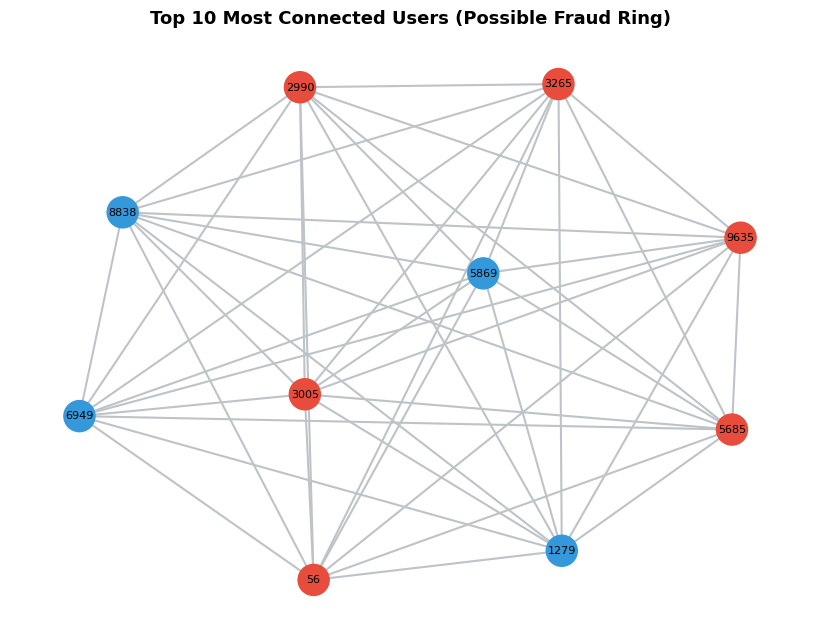

In [26]:
# Visualize top 10 most connected users
top_10_users = [user for user, score in top_users[:10]]
subgraph_top = G.subgraph(top_10_users)

plt.figure(figsize=(8, 6))

colors_top = ['#e74c3c' if node in fraud_users_set
              else '#3498db' for node in subgraph_top.nodes()]

pos_top = nx.spring_layout(subgraph_top, seed=42)
nx.draw(subgraph_top,
        pos=pos_top,
        node_color=colors_top,
        node_size=500,
        with_labels=True,
        font_size=8,
        edge_color='#bdc3c7',
        width=1.5)

plt.title('Top 10 Most Connected Users (Possible Fraud Ring)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
from networkx.algorithms import community

if G.number_of_nodes() <= 500:
    communities = community.greedy_modularity_communities(G)
    print(f"Total communities found: {len(communities)}")
    for i, comm in enumerate(list(communities)[:5]):
        print(f"Community {i+1}: {list(comm)[:5]}...")
else:
    print("Graph too large — reduce sample size")

Total communities found: 1
Community 1: [np.int64(9216), np.int64(8193), np.int64(9219), np.int64(5125), np.int64(8199)]...


In [28]:
# Install (run once in Colab)
!pip install shap

# Imports
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

In [30]:
X_test_df = pd.DataFrame(
    xgb_scaler.inverse_transform(X_test),
    columns=X.columns
)

In [31]:
model = rf  # your trained model

explainer = shap.Explainer(model, X_test_df)
shap_values = explainer(X_test_df)

 99%|===================| 17802/18000 [00:23<00:00]       

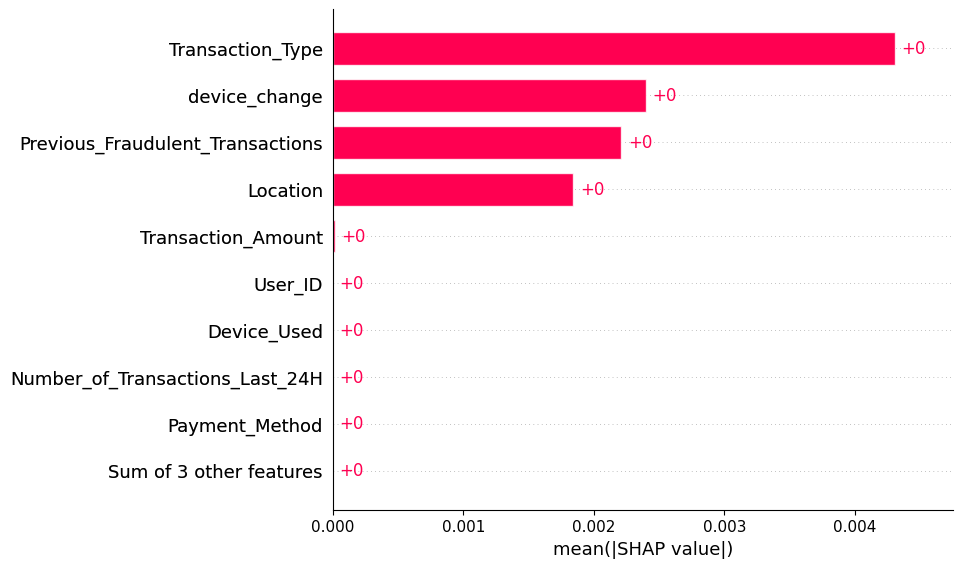

In [32]:
shap.plots.bar(shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[1],
    data=shap_values.data,
    feature_names=shap_values.feature_names
))

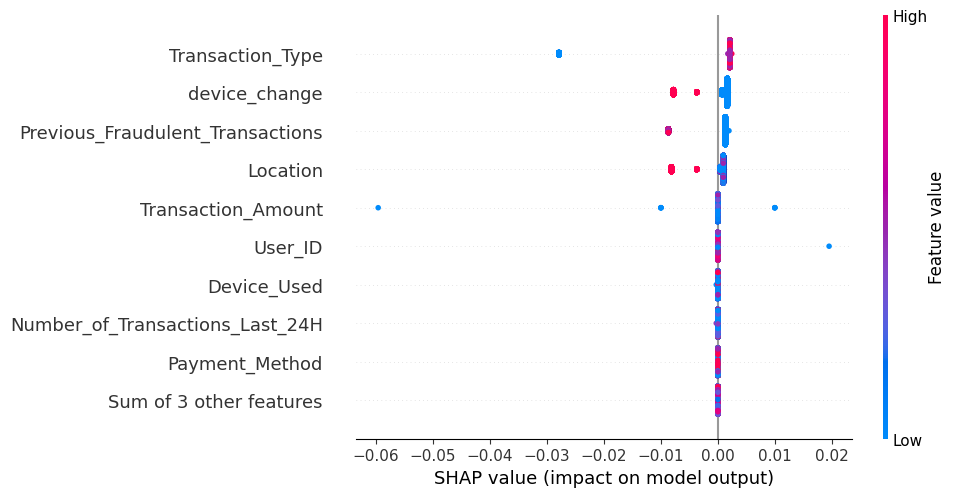

In [33]:
shap.plots.beeswarm(shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[1],
    data=shap_values.data,
    feature_names=shap_values.feature_names
))

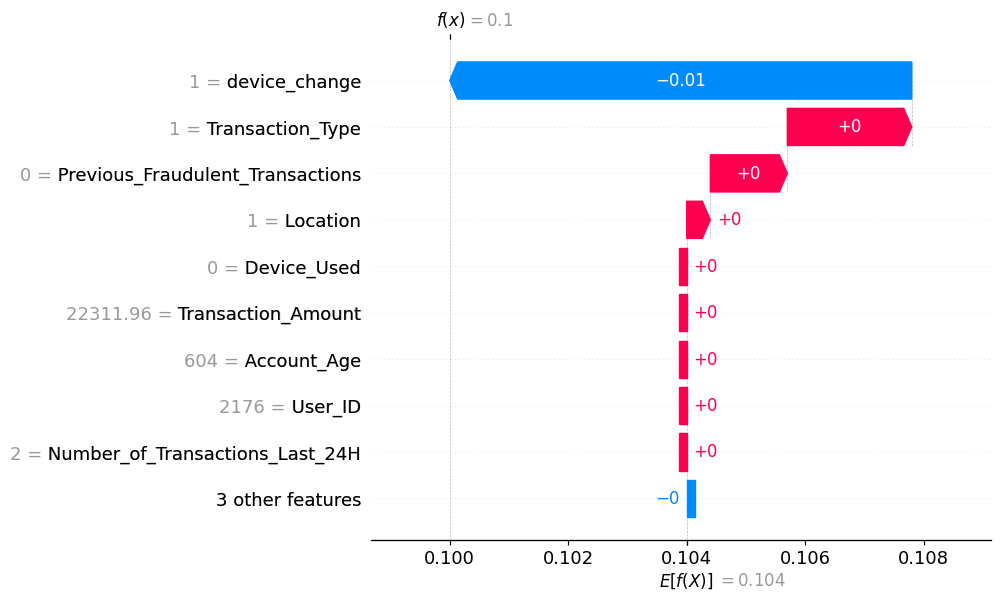

In [34]:
index = 0
shap.plots.waterfall(shap_values[index, :, 1])

In [35]:
index = 0

print("Transaction Explanation:\n")

for feature, value, impact_array in zip(
    X_test_df.columns,
    X_test_df.iloc[index],
    shap_values[index].values
):
    impact = impact_array[1] # Get impact for the fraudulent class (class 1)
    print(f"{feature} = {value} → Impact: {impact:.4f}")

Transaction Explanation:

User_ID = 2176.0 → Impact: 0.0000
Transaction_Amount = 22311.960000000006 → Impact: 0.0000
Transaction_Type = 1.0 → Impact: 0.0021
Device_Used = 0.0 → Impact: 0.0000
Location = 1.0 → Impact: 0.0004
Previous_Fraudulent_Transactions = 0.0 → Impact: 0.0013
Account_Age = 604.0 → Impact: 0.0000
Number_of_Transactions_Last_24H = 2.0 → Impact: 0.0000
Payment_Method = 1.0 → Impact: 0.0000
Hour = 13.0 → Impact: 0.0000
night_txn = 0.0 → Impact: 0.0000
device_change = 1.0 → Impact: -0.0078


In [36]:
explanation = pd.DataFrame({
    "Feature": X_test_df.columns,
    "Value": X_test_df.iloc[index],
    "Impact": shap_values[index].values[:, 1] # Select impact for class 1 (fraudulent)
})

explanation["AbsImpact"] = np.abs(explanation["Impact"])

explanation = explanation.sort_values(by="AbsImpact", ascending=False)

print(explanation.head(5))

                                                           Feature  Value  \
device_change                                        device_change    1.0   
Transaction_Type                                  Transaction_Type    1.0   
Previous_Fraudulent_Transactions  Previous_Fraudulent_Transactions    0.0   
Location                                                  Location    1.0   
Device_Used                                            Device_Used    0.0   

                                  Impact  AbsImpact  
device_change                    -0.0078     0.0078  
Transaction_Type                  0.0021     0.0021  
Previous_Fraudulent_Transactions  0.0013     0.0013  
Location                          0.0004     0.0004  
Device_Used                       0.0000     0.0000  


In [37]:
# Safety check — make sure all_idx exists from autoencoder cell
if 'all_idx' not in dir():
    all_idx = np.random.choice(len(X_scaled), size=min(30000, len(X_scaled)), replace=False)
    X_sample = X_scaled[all_idx]
    y_sample = np.array(y)[all_idx]
    print("⚠️ all_idx was not found — re-generated. Please run Cell 10 first for best results.")

In [38]:
# ── Save MSE reference stats for normalization in production ──
# Run on a sample of normal transactions to get the normalization baseline
normal_sample_idx = np.where(y == 0)[0][:5000]
X_normal_sample = X_scaled[normal_sample_idx]

recon_normal = autoencoder.predict(X_normal_sample, verbose=0)
mse_normal = np.mean(np.power(X_normal_sample - recon_normal, 2), axis=1)

mse_p95 = float(np.percentile(mse_normal, 95))   # fraud threshold reference
mse_p50 = float(np.percentile(mse_normal, 50))   # median for normalization

print(f"MSE p50 (normal median): {mse_p50:.6f}")
print(f"MSE p95 (anomaly threshold): {mse_p95:.6f}")

import joblib
joblib.dump({'p50': mse_p50, 'p95': mse_p95}, drive_path + 'mse_stats.pkl')
print("✅ mse_stats.pkl saved")

MSE p50 (normal median): 1.952122
MSE p95 (anomaly threshold): 3.351494
✅ mse_stats.pkl saved


In [39]:
# ====================================================
# TRUE HYBRID ENSEMBLE — All models combined
# Supervised (XGBoost) + Unsupervised (Autoencoder + LOF + KMeans)
# ====================================================

import joblib
import numpy as np
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans

drive_path = '/content/drive/MyDrive/Colab Notebooks/'

# Load Brinda's best supervised model (whichever was auto-selected)
xgb_model    = joblib.load(drive_path + 'final_fraud_model.pkl')
xgb_scaler   = joblib.load(drive_path + 'scaler.pkl')
xgb_features = joblib.load(drive_path + 'feature_list.pkl')

print("✅ Loaded best supervised model")
print(f"Features: {xgb_features}")

# Make sure X_sample and y_sample are available (from autoencoder cell)
if 'all_idx' not in dir():
    all_idx  = np.random.choice(len(X_scaled), size=min(30000, len(X_scaled)), replace=False)
    X_sample = X_scaled[all_idx]
    y_sample = np.array(y)[all_idx]

y_true = np.array(y)[all_idx]

# ── 1. XGBoost supervised probability ───────────────────────────────────────
X_xgb_scaled = xgb_scaler.transform(X_sample)
xgb_probs    = xgb_model.predict_proba(X_xgb_scaled)[:, 1]
print("✅ XGBoost probabilities computed")

# ── 2. Autoencoder anomaly score (MSE normalized) ───────────────────────────
reconstructions = autoencoder.predict(X_sample, verbose=0)
mse_scores      = np.mean(np.power(X_sample - reconstructions, 2), axis=1)
ae_norm         = (mse_scores - mse_scores.min()) / (mse_scores.max() - mse_scores.min())
print("✅ Autoencoder MSE scores computed")

# ── 3. LOF anomaly score ─────────────────────────────────────────────────────
# Use a subsample for LOF (it's slow on large data)
lof_size = min(8000, len(X_sample))
lof_idx  = np.random.choice(len(X_sample), size=lof_size, replace=False)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1, novelty=False)
lof.fit(X_sample[lof_idx])

# Score all samples: negative_outlier_factor_ not available for new data,
# so we fit+predict on the full sample using novelty=False approach
lof_full       = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
lof_raw        = lof_full.fit(X_sample).negative_outlier_factor_
# Convert: more negative = more anomalous → flip and normalize to 0–1
lof_score      = -lof_raw   # now higher = more anomalous
lof_norm       = (lof_score - lof_score.min()) / (lof_score.max() - lof_score.min())
print("✅ LOF scores computed")

# ── 4. K-Means anomaly score ─────────────────────────────────────────────────
kmeans_ens    = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_ens.fit(X_sample)
distances     = np.min(kmeans_ens.transform(X_sample), axis=1)
km_norm       = (distances - distances.min()) / (distances.max() - distances.min())
print("✅ K-Means scores computed")

# ── 5. Combine all 4 scores into one hybrid ensemble score ──────────────────
# Weights: XGBoost 50% (supervised, most reliable)
#          Autoencoder 25% (unsupervised, reconstruction-based)
#          LOF 15%         (density-based)
#          K-Means 10%     (distance-based)
hybrid_score = (0.50 * xgb_probs +
                0.25 * ae_norm   +
                0.15 * lof_norm  +
                0.10 * km_norm)

print("\n" + "="*60)
print("   WEIGHTS USED IN ENSEMBLE")
print("="*60)
print("  XGBoost (supervised)     → 50%")
print("  Autoencoder (unsupervised) → 25%")
print("  LOF (unsupervised)       → 15%")
print("  K-Means (unsupervised)   → 10%")
print("="*60)

# ── 6. Find best threshold for hybrid score ──────────────────────────────────
best_f1, best_thresh = 0, 0.5
for t in np.arange(0.05, 0.95, 0.01):
    preds = (hybrid_score >= t).astype(int)
    if preds.sum() == 0:
        continue
    f1 = f1_score(y_true, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, float(t)

hybrid_preds = (hybrid_score >= best_thresh).astype(int)

print(f"\n✅ Best threshold: {best_thresh:.2f}")
print("\n" + "="*60)
print("   FULL HYBRID ENSEMBLE RESULTS (All 4 Models)")
print("="*60)
print(classification_report(y_true, hybrid_preds))
print(f"ROC-AUC: {roc_auc_score(y_true, hybrid_score):.4f}")

# ── 7. Final comparison: each model alone vs full ensemble ───────────────────
print("\n" + "="*60)
print("   INDIVIDUAL vs ENSEMBLE COMPARISON")
print("="*60)
print(f"{'Method':<32} {'F1':>8} {'ROC-AUC':>10}")
print("-"*52)

xgb_preds_alone = (xgb_probs >= 0.5).astype(int)
ae_thresh       = np.percentile(ae_norm, 95)
ae_preds        = (ae_norm > ae_thresh).astype(int)
lof_preds       = (lof_norm > np.percentile(lof_norm, 90)).astype(int)
km_preds        = (km_norm > np.percentile(km_norm, 90)).astype(int)

print(f"{'XGBoost (supervised)':<32} {f1_score(y_true, xgb_preds_alone):>8.4f} {roc_auc_score(y_true, xgb_probs):>10.4f}")
print(f"{'Autoencoder (unsupervised)':<32} {f1_score(y_true, ae_preds):>8.4f} {roc_auc_score(y_true, ae_norm):>10.4f}")
print(f"{'LOF (unsupervised)':<32} {f1_score(y_true, lof_preds):>8.4f} {roc_auc_score(y_true, lof_norm):>10.4f}")
print(f"{'K-Means (unsupervised)':<32} {f1_score(y_true, km_preds):>8.4f} {roc_auc_score(y_true, km_norm):>10.4f}")
print(f"{'Full Hybrid Ensemble':<32} {best_f1:>8.4f} {roc_auc_score(y_true, hybrid_score):>10.4f}")
print("="*52)
print("✅ Full hybrid ensemble complete — all models contributed")

# ── Save full 4-model hybrid threshold (for reference/analysis) ──────────────
joblib.dump(best_thresh, drive_path + 'hybrid_threshold_4model.pkl')
print(f"\n✅ 4-model hybrid threshold saved (for reference): {best_thresh:.4f}")

# ====================================================
# ✅ FIX: Retune threshold for PRODUCTION formula
# app.py uses: 0.70 * XGBoost + 0.30 * Autoencoder (no LOF, no KMeans)
# The threshold must be calibrated against THIS formula, not the 4-model one
# ====================================================

# Normalize autoencoder MSE the same way app.py does (using p50/p95 from mse_stats)
_mse_p50 = mse_p50
_mse_p95 = mse_p95
ae_prod_norm = np.clip((mse_scores - _mse_p50) / (_mse_p95 - _mse_p50), 0, 1)

# Compute production hybrid score (matches app.py exactly)
prod_hybrid_score = 0.70 * xgb_probs + 0.30 * ae_prod_norm

# Tune threshold against production formula
best_prod_f1, best_prod_thresh = 0, 0.5
for t in np.arange(0.05, 0.95, 0.01):
    preds = (prod_hybrid_score >= t).astype(int)
    if preds.sum() == 0:
        continue
    f1 = f1_score(y_true, preds)
    if f1 > best_prod_f1:
        best_prod_f1, best_prod_thresh = f1, float(t)

prod_preds = (prod_hybrid_score >= best_prod_thresh).astype(int)
print(f"\n✅ Production hybrid threshold (2-model): {best_prod_thresh:.2f} | F1: {best_prod_f1:.4f}")
print(classification_report(y_true, prod_preds))

# Save production threshold — this is what app.py loads
joblib.dump(best_prod_thresh, drive_path + 'hybrid_threshold.pkl')
print("✅ hybrid_threshold.pkl saved (calibrated for production 2-model formula)")

# Save autoencoder
autoencoder.save(drive_path + 'autoencoder_model.keras')
autoencoder.save_weights(drive_path + 'autoencoder_weights.weights.h5')
print("✅ autoencoder_model.keras saved")
print("✅ autoencoder_weights.weights.h5 saved")

✅ Loaded best supervised model
Features: ['User_ID', 'Transaction_Amount', 'Transaction_Type', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Hour', 'night_txn', 'device_change']
✅ XGBoost probabilities computed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ Autoencoder MSE scores computed
✅ LOF scores computed
✅ K-Means scores computed

   WEIGHTS USED IN ENSEMBLE
  XGBoost (supervised)     → 50%
  Autoencoder (unsupervised) → 25%
  LOF (unsupervised)       → 15%
  K-Means (unsupervised)   → 10%

✅ Best threshold: 0.31

   FULL HYBRID ENSEMBLE RESULTS (All 4 Models)
              precision    recall  f1-score   support

           0       1.00      0.68      0.81     29949
           1       0.00      0.27      0.00        51

    accuracy                           0.68     30000
   macro avg       0.50      0.48      0.41     30000
weighted avg       1.00      0.68      0.81     30000

ROC-AUC: 0.4821

   INDIVIDUAL vs ENSEMBLE COMPARISON
Method                                 F1    ROC-AUC
----------------------------------------------------
XGBoost (supervised)               0.0023     0.3693
Autoencoder (unsupervised)         0.0297     0.8246
LOF (unsupervised)                 0.0197     0.8221
K-Means (unsupervised)             0.

In [40]:
joblib.dump(rf, '/content/drive/MyDrive/Colab Notebooks/rf_model.pkl')

['/content/drive/MyDrive/Colab Notebooks/rf_model.pkl']